# Dependencies And Data Import


In [ ]:
!pip install tensorflow matplotlib tensorflow-datasets ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.3 MB/s eta 0:00:00


In [ ]:

!pip list


Package                                  Version
---------------------------------------- ------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.5
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                          

In [ ]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
import tensorflow_datasets as tfds
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
ds = tfds.load('fashion_mnist', split='train')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.3CQUVQ_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.3CQUVQ_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


In [ ]:

ds.as_numpy_iterator().next()['label']

np.int64(2)

In [ ]:
data_iterator = ds.as_numpy_iterator()

In [ ]:
#gives data out of the pipeline
data_iterator.next()

{'image': array([[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 18],
         [ 77],
         [227],
         [227],
         [208],
         [210],
         [225],
         [216],
         [ 85],
         [ 32],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 61],
         [100],
         [ 97],
         [ 80],
         [ 57],
         [117],
         [227],
         [238],
         [115],
         [ 49],
         [ 78],
         [106],
         [108],
         [ 71],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         

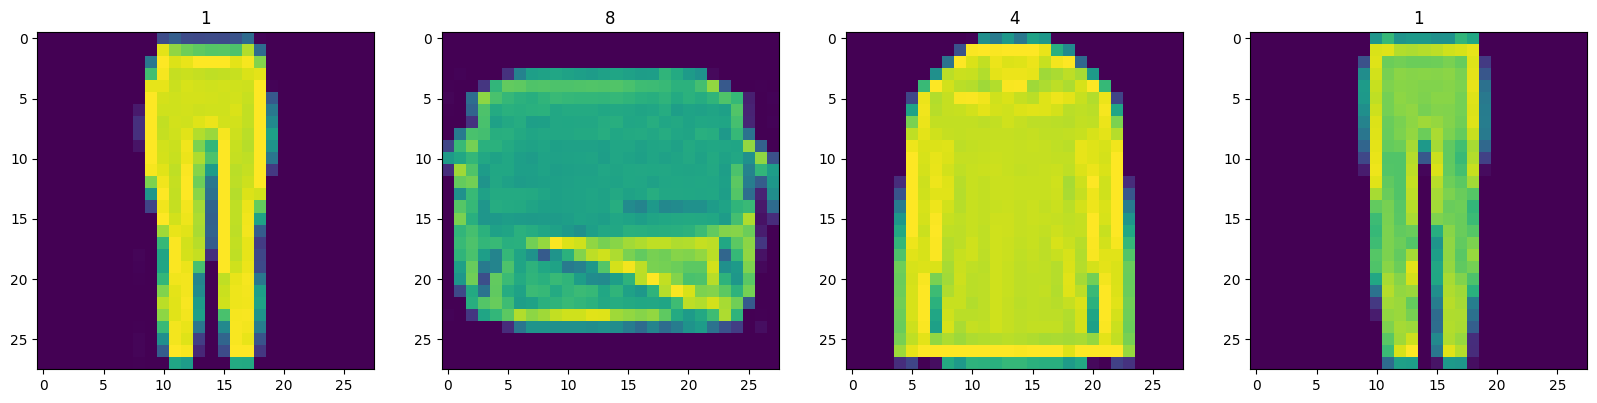

In [ ]:
fig,ax = plt.subplots(ncols=4,figsize=(20,20))
for idx in range(4):
  batch = data_iterator.next()
  ax[idx].imshow(np.squeeze(batch['image']))
  ax[idx].title.set_text(batch['label'])

In [ ]:
def scalar_image(data):
  image = data['image']
  return image / 255

In [ ]:
#running the datasets throught the scaler_images processing steps
ds = ds.map(scalar_image)

#caching out datasets for that batch(store your dataset in memory (or disk) after the first pass and fast access as well)
ds = ds.cache()

#sampling out
ds = ds.shuffle(60000)

#batch into 128 images per sample
ds = ds.batch(128)

#reduce the likelihood of bottlenecking
#prepare the next batches while your model is training on the current one.
ds = ds.prefetch(64)

In [ ]:
ds.as_numpy_iterator().next().shape

(128, 28, 28, 1)

# Build Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Reshape,LeakyReLU,Dropout,UpSampling2D

In [ ]:
# Why 7×7? Because
# Final image = 28×28
# 7 → 14 → 28 (doubling using UpSampling2D )
def generator():
  model = Sequential()

  model.add(Dense(128*7*7,input_dim=128))
  model.add(LeakyReLU(0.2))
  model.add(Reshape((7,7,128)))

  #First Upsampling Block
  model.add(UpSampling2D())
  # filter(number of filters in the convolution || dimension of output space),kernal(specifing the size of convolution window),padding="valid(no padding)
  # or same(padding evenly to the left/right or up/down of the input)"
  # First parameter = number of filters
  # Kernel size = size of each filter
  #for same padding is add which increase dim(n+2,m+2) but after apply conv then come back to same (n,m)
  model.add(Conv2D(128,5,padding='same'))
  model.add(LeakyReLU(0.2))

  model.add(UpSampling2D())
  model.add(Conv2D(128,5,padding='same'))
  model.add(LeakyReLU(0.2))

  model.add(Conv2D(128,4,padding='same'))
  model.add(LeakyReLU(0.2))

  model.add(Conv2D(128,4,padding='same'))
  model.add(LeakyReLU(0.2))

  #convolution layer to get to one channel and sigmoid for values b/w 0 and 1
  model.add(Conv2D(1,4,activation='sigmoid',padding='same'))

  return model

In [ ]:
test = generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
test.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,155,137 (8.22 MB)

 Trainable params: 2,155,137 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
img = test.predict(np.random.randn(4,128,1))
img.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(4, 28, 28, 1)

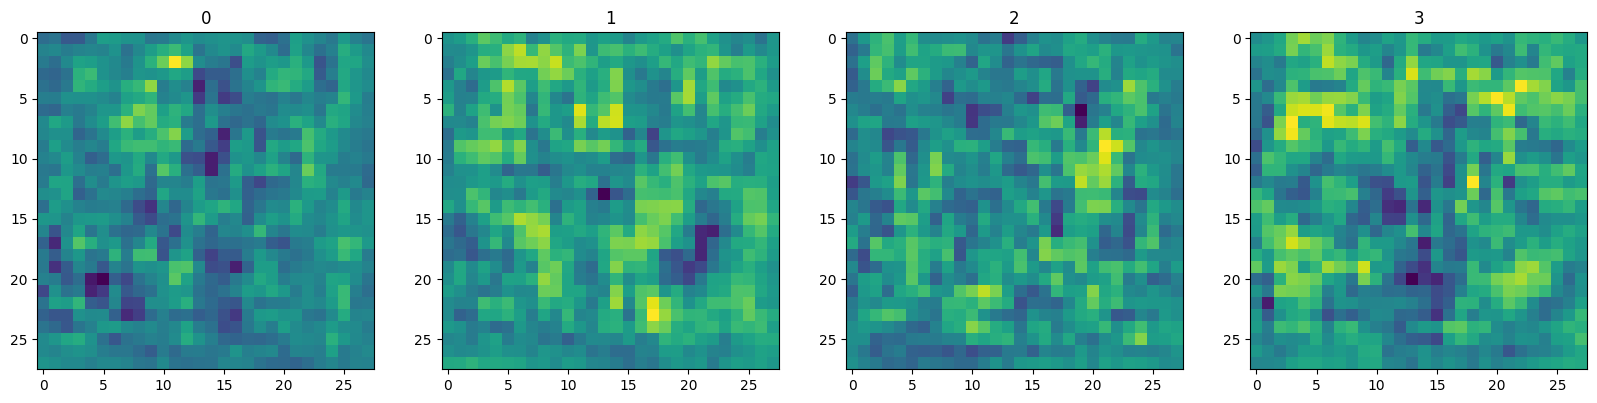

In [ ]:
fig,ax = plt.subplots(ncols=4,figsize=(20,20))
for idx,i in enumerate(img):
  ax[idx].imshow(np.squeeze(i))
  ax[idx].title.set_text(idx)

# Discriminator

In [ ]:
def build_discriminator():

    model = Sequential()
    model.add(Conv2D(32, 5, input_shape=[28, 28, 1]))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    model.add(Conv2D(64, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    model.add(Conv2D(128, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    model.add(Conv2D(256, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))

    return model

In [ ]:
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        36,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113,345 (4.25 MB)

 Trainable params: 1,113,345 (4.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
discriminator.predict(img)# this expect a batch of images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step


array([[0.5093743],
       [0.5094665],
       [0.5095686],
       [0.5094901]], dtype=float32)

In [ ]:
#for a single image use this
discriminator.predict(np.expand_dims(img[0],axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step


array([[0.5093743]], dtype=float32)

In [ ]:
img.shape

(4, 28, 28, 1)

# Traning Loop

In [ ]:
# Generally tough part while practicing with GAN as we have to find a balance b/w speed of generator learns and discriminator trains

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
g_opt = Adam(learning_rate=1e-4)
d_opt = Adam(learning_rate=5e-5)
g_loss = BinaryCrossentropy()
d_loss = BinaryCrossentropy()

In [ ]:
class FashionGAN(Model):
  def __init__(self,generator,discriminator,*args,**kwargs):
    super().__init__(*args,**kwargs)
    self.generator = generator
    self.discriminator = discriminator

  def compile(self,g_opt,d_opt,g_loss,d_loss,*args,**kwargs):
    super().compile(*args,**kwargs)
    self.g_opt = g_opt
    self.d_opt = d_opt
    self.g_loss = g_loss
    self.d_loss = d_loss

  def call(self, inputs):
    batch_size = tf.shape(inputs)[0]
    noise = tf.random.normal((batch_size, 128))
    return self.generator(noise)

  def train_step(self,batch):
    real_image = batch
    batch_size = tf.shape(real_image)[0]
    noise = tf.random.normal((batch_size, 128))
    fake_image = self.generator(noise, training=True)

    with tf.GradientTape() as d_tape:
      #Pass the real and fake image into the discriminator
      yhat_real = self.discriminator(real_image,training=True)
      yhat_fake = self.discriminator(fake_image,training=True)
      yhat_realfake = tf.concat([yhat_real,yhat_fake],axis=0)

      #Label added
      y_realfake = tf.concat([tf.zeros_like(yhat_real),tf.ones_like(yhat_fake)],axis=0)

      #some noise add to true outputs
      noise_real = 0.15 * tf.random.uniform(tf.shape(yhat_real))
      noise_fake = -0.15 * tf.random.uniform(tf.shape(yhat_fake))
      y_realfake += tf.concat([noise_real,noise_fake],axis=0)

      #loss calculation
      total_d_loss = self.d_loss(y_realfake,yhat_realfake)

    d_gradient = d_tape.gradient(total_d_loss,self.discriminator.trainable_variables)
    self.d_opt.apply_gradients(zip(d_gradient,self.discriminator.trainable_variables))

    with tf.GradientTape() as g_tape:
      gan_fake = self.generator(tf.random.normal((128,128,1)), training=True)
      pred_labels = self.discriminator(gan_fake,training=False)
      #trying to faking out the discriminator by telling the generated image is real
      total_g_loss = self.g_loss(tf.zeros_like(pred_labels),pred_labels)

    g_gradient = g_tape.gradient(total_g_loss,self.generator.trainable_variables)
    self.g_opt.apply_gradients(zip(g_gradient,self.generator.trainable_variables))

    return {"d_loss": total_d_loss, "g_loss": total_g_loss}

In [ ]:
fashGan = FashionGAN(test,discriminator)

In [ ]:
fashGan(tf.random.normal((1,28,28,1)))

<tf.Tensor: shape=(1, 28, 28, 1), dtype=float32, numpy=
array([[[[0.502536  ],
         [0.4980611 ],
         [0.50462884],
         [0.5041434 ],
         [0.50262684],
         [0.5033274 ],
         [0.50585836],
         [0.4997885 ],
         [0.5022905 ],
         [0.5002282 ],
         [0.50469697],
         [0.49765605],
         [0.49396673],
         [0.50144976],
         [0.4941043 ],
         [0.4968601 ],
         [0.49981558],
         [0.50610137],
         [0.4991765 ],
         [0.49480283],
         [0.4975905 ],
         [0.5009024 ],
         [0.49596986],
         [0.49873567],
         [0.50236225],
         [0.4979017 ],
         [0.49953404],
         [0.49973205]],

        [[0.49995267],
         [0.49801284],
         [0.5041831 ],
         [0.5031055 ],
         [0.49289677],
         [0.4991782 ],
         [0.50460285],
         [0.50653845],
         [0.50021636],
         [0.49254206],
         [0.50520104],
         [0.49963018],
         [0.5010833 ],

In [ ]:
gen = generator()
disc = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
gen(tf.random.normal((1,128)))
disc(tf.random.normal((1,28,28,1)))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.5094935]], dtype=float32)>

In [ ]:
fashGan.compile(g_opt,d_opt,g_loss,d_loss)

In [ ]:
import os
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

In [ ]:
class ModelMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        # 1. Generate noise (normal distribution)
        random_latent_vectors = tf.random.normal((self.num_img, self.latent_dim))

        # 2. Generate images (in inference mode)
        generated_img = self.model.generator(random_latent_vectors, training=False)

        # 3. Scale to [0,255]
        generated_img = generated_img * 255.0
        generated_img = generated_img.numpy()

        # 4. Save images
        for i in range(self.num_img):
            img = array_to_img(generated_img[i])
            img.save(os.path.join('images', f'generated_img_{epoch}_{i}.png'))

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "gan_checkpoint.weights.h5",
    save_weights_only=True,
    save_freq='epoch'
)

In [ ]:
hist = fashGan.fit(ds,epochs=200,callbacks=[ModelMonitor(),checkpoint_cb])

Epoch 1/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 184ms/step - d_loss: 0.8134 - g_loss: 1.3058
Epoch 2/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - d_loss: 0.5019 - g_loss: 1.1074
Epoch 3/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - d_loss: 0.2942 - g_loss: 0.8727
Epoch 4/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - d_loss: 0.6599 - g_loss: 0.5996
Epoch 5/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - d_loss: 0.6398 - g_loss: 0.6056
Epoch 6/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - d_loss: 0.6146 - g_loss: 0.7688
Epoch 7/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - d_loss: 0.7408 - g_loss: 0.5894
Epoch 8/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 152ms/step - d_loss: 0.6389 - g_loss: 0.9445
Epoch 9/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 152ms/step - d_loss: 0.6931 - g_loss: 0.7183
Epoch 10/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - d_loss: 0.6094 - g_loss: 0.9086
Epoch 11/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 151ms/step - d_loss: 0.6006 - g_loss: 0.5080
Epoch 1

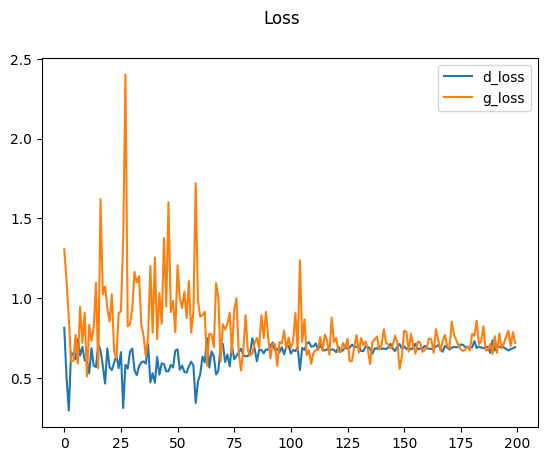

In [ ]:
plt.suptitle('Loss')
plt.plot(hist.history['d_loss'], label='d_loss')
plt.plot(hist.history['g_loss'], label='g_loss')
plt.legend()
plt.show()

In [ ]:
dummy = tf.random.normal((1, 128))  # correct shape
test(dummy)

<tf.Tensor: shape=(1, 28, 28, 1), dtype=float32, numpy=
array([[[[1.66372285e-08],
         [1.85266794e-15],
         [8.20362421e-15],
         [4.67392401e-13],
         [1.41793535e-10],
         [8.27447906e-08],
         [1.53158944e-05],
         [8.45334120e-03],
         [1.84892520e-01],
         [3.70065987e-01],
         [6.53579593e-01],
         [8.04409564e-01],
         [8.84903312e-01],
         [5.91153741e-01],
         [4.65226769e-01],
         [7.11830616e-01],
         [8.81504476e-01],
         [6.00941122e-01],
         [1.74674764e-01],
         [2.86000557e-02],
         [2.15579337e-03],
         [2.14751111e-04],
         [1.16480776e-04],
         [2.16637645e-03],
         [2.09074983e-06],
         [4.08754630e-09],
         [3.40825795e-06],
         [6.80563098e-04]],

        [[1.75598414e-09],
         [2.43714482e-15],
         [2.77120784e-15],
         [3.79941287e-15],
         [1.61473737e-10],
         [6.22577723e-09],
         [1.04165991e-07

In [ ]:
imgs = test.predict(tf.random.normal((16, 128, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


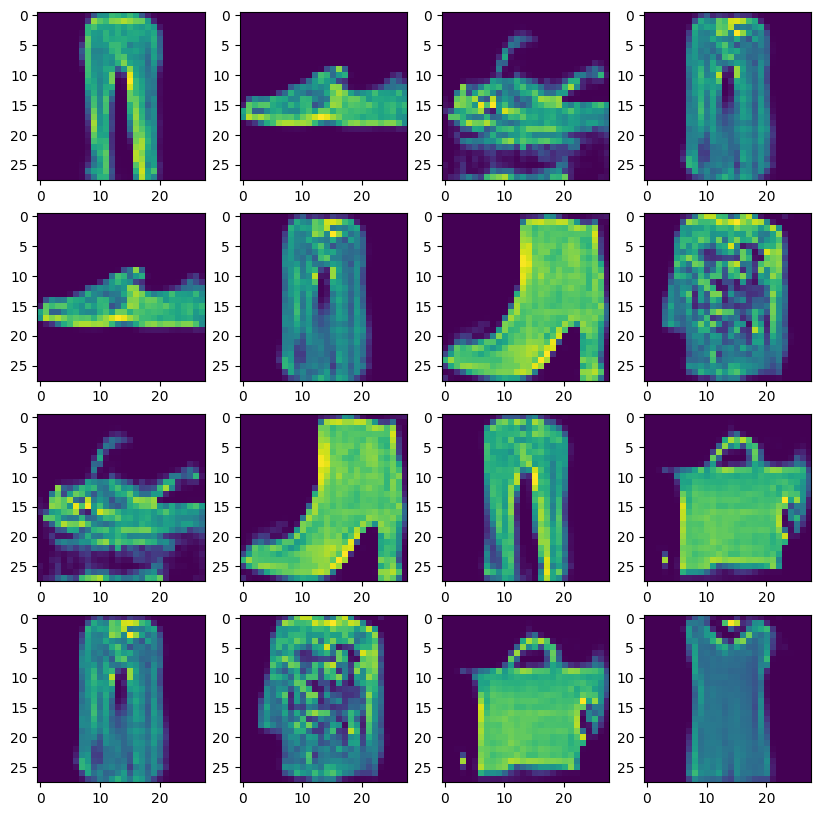

In [ ]:
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(10,10))
for r in range(4):
    for c in range(4):
        ax[r][c].imshow(imgs[(r+1)*(c+1)-1])